# Case-08.2:雙筋梁 + T 形梁設計

依 [ROADMAP.md](../ROADMAP.md) 規劃,延續 Case-08.1 的 `design_rebar()`,
這裡處理單筋矩形梁不夠用的兩種情況:

1. **雙筋梁**:當彎矩需求超過單筋斷面在拉力控制極限下的容量,加壓力
   鋼筋補足
2. **T 形梁**:梁跟樓板整體澆置,受壓翼板寬度遠大於梁寬,要另外處理

**這一課有一個真實踩到的計算 bug,誠實記錄**:雙筋梁設計第一版算出來
的 $\phi M_n$ 比需求少了約 10%,追查後發現是計算 $A_{s2}$(力偶部分
額外拉力鋼筋)那條公式漏除了 $\phi=0.9$——已修正,下面會看到修正
前後的對照。

## 第 1 課:雙筋梁設計——先算單筋能扛多少,不夠才加壓力筋

**設計邏輯**(標準教科書做法,分兩部分疊加):
1. 先算單筋斷面在**拉力控制極限**($\varepsilon_t=0.005$)下能扛的
   彎矩 $M_{u1}$,對應鋼筋量 $A_{s1}$
2. 如果需求 $M_u > M_{u1}$,剩餘的 $M_{u2}=M_u-M_{u1}$ 用一對「壓力
   鋼筋 $A_s'$ + 額外拉力鋼筋 $A_{s2}$」的力偶承擔(兩者對中性軸的
   力矩互相平衡,只提供彎矩,不提供淨壓力)
3. **關鍵檢查點,很多簡化教材會漏掉**:壓力鋼筋不一定真的降伏,要
   用單筋部分算出來的中性軸深度 $c_{max}$ 反推壓力筋位置的應變,
   確認 $\varepsilon_s' \geq \varepsilon_y$ 才能直接假設 $f_s'=f_y$
   ——沒降伏的話要用實際應力 $f_s'=E_s\varepsilon_s'$,鋼筋量要
   放大。

## 環境設置

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
import os
if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section

print("rc_design模組已載入: design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section")

rc_design模組已載入: design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section


## 第 2 課:設計案例——一根需要雙筋的大彎矩梁

用一根 30×50cm 梁,故意給一個超過單筋極限的大彎矩($M_u=420$
kN-m),逼出雙筋設計的完整流程。

In [3]:
CASE_DR = dict(Mu_kNm=420.0, b_cm=30.0, h_cm=50.0, d_prime_cm=6.0)
r = design_doubly_reinforced(**CASE_DR)

print(f"單筋斷面在拉力控制極限下的容量 Mu1 = {r['Mu1']:.2f} kN-m")
print(f"需求 Mu = {CASE_DR['Mu_kNm']:.2f} kN-m")

if r['need_doubly']:
    print(f"Mu > Mu1, 需要雙筋設計\n")
    print(f"壓力鋼筋位置應變 eps_s' = {r['eps_s_prime']:.5f}")
    if r['compression_yields']:
        print("[PASS] 壓力鋼筋確實降伏, As'=As2")
    else:
        print(f"[注意] 壓力鋼筋未降伏, fs'={r['fs_prime']:.1f}kgf/cm^2, 已放大As'")

    print(f"\nAs1(單筋部分) = {r['As1']:.3f} cm^2")
    print(f"As2(力偶部分, 也是額外拉力鋼筋) = {r['As2']:.3f} cm^2")
    print(f"As總計(拉力鋼筋) = {r['As_total']:.3f} cm^2")
    print(f"As'(壓力鋼筋) = {r['As_prime']:.3f} cm^2")
else:
    print(f"Mu <= Mu1, 單筋斷面就夠了, 不需要雙筋設計")
    print(f"這個案例請改用 design_rebar()(Case-08.1), 不要用這個函式硬做雙筋")

assert r['need_doubly'], f"CASE_DR(Mu={CASE_DR['Mu_kNm']})應該要觸發雙筋設計, 用來示範雙筋流程——若改了b_cm/h_cm導致這裡失敗, 代表也要跟著調高Mu_kNm"
print("\n[PASS] 雙筋設計邏輯正確觸發")


單筋斷面在拉力控制極限下的容量 Mu1 = 291.93 kN-m
需求 Mu = 420.00 kN-m
Mu > Mu1, 需要雙筋設計

壓力鋼筋位置應變 eps_s' = 0.00185
[注意] 壓力鋼筋未降伏, fs'=3691.2kgf/cm^2, 已放大As'

As1(單筋部分) = 22.531 cm^2
As2(力偶部分, 也是額外拉力鋼筋) = 9.710 cm^2
As總計(拉力鋼筋) = 32.241 cm^2
As'(壓力鋼筋) = 11.048 cm^2

[PASS] 雙筋設計邏輯正確觸發


## 第 3 課:交叉驗證——應變相容法(含壓力鋼筋)

跟 08.1 同一套精神,獨立算一次,不只信任公式解本身。**這裡順便留下
第一版 bug 的對照**:第一版 $A_{s2}$ 漏除 $\phi$,算出來的鋼筋量
偏少,用應變相容法驗證時 $\phi M_n$ 只有 377.34 kN-m,跟需求
420 差了 10.16%——正是這個交叉驗證抓到問題的。

In [4]:
def verify_doubly_reinforced(r, b_cm, d_prime_cm, h_cm, fc=280.0, fy=4200.0, Es=2.0e6,
                               beta1=0.85, eps_cu=0.003):
    d = r['d']
    As_total = r['As_total']
    As_prime = r['As_prime']

    def section_force(c):
        a = min(beta1*c, h_cm)
        Cc = 0.85*fc*b_cm*a
        eps_y = fy/Es
        eps_s_prime = eps_cu*(c-d_prime_cm)/c if c > 0 else 0
        eps_s_prime = max(min(eps_s_prime, eps_y), -eps_y)
        fs_prime = Es*eps_s_prime
        Cs = As_prime*(fs_prime - 0.85*fc if d_prime_cm <= a else fs_prime)
        eps_s = eps_cu*(c-d)/c if c > 0 else 0
        eps_s = max(min(eps_s, eps_y), -eps_y)
        fs = Es*eps_s
        Ts = As_total*fs
        N = Cc + Cs + Ts
        M = Cc*(d-a/2) + Cs*(d-d_prime_cm)
        return N, M

    c_lo, c_hi = 0.1, h_cm
    for _ in range(100):
        c_mid = (c_lo+c_hi)/2
        N, _ = section_force(c_mid)
        if N > 0: c_hi = c_mid
        else: c_lo = c_mid
    _, M_final = section_force((c_lo+c_hi)/2)
    Mn_kNm = M_final*9.80665e-5
    return 0.9*Mn_kNm


if r['need_doubly']:
    # 驗證吃CASE_DR的實際參數, 不是另外寫死一組數字——CASE_DR改了這裡自動跟著改
    phiMn_check = verify_doubly_reinforced(
        r, b_cm=CASE_DR['b_cm'], d_prime_cm=CASE_DR['d_prime_cm'], h_cm=CASE_DR['h_cm']
    )
    print(f"應變相容法(修正後): phiMn = {phiMn_check:.2f} kN-m")
    print(f"對照需求 Mu = {CASE_DR['Mu_kNm']:.2f} kN-m")
    diff = abs(phiMn_check-CASE_DR['Mu_kNm'])/CASE_DR['Mu_kNm']
    print(f"差異 = {diff:.2%}")

    assert diff < 0.02, "修正後應變相容法與設計公式應該吻合在2%以內"
    print("\n[PASS] 雙筋梁設計公式(修正phi遺漏後)與應變相容法互相驗證通過")
else:
    print("上一格 r['need_doubly']=False, 這一格的應變相容法驗證跳過")
    print("(這格是專門驗證雙筋設計的, Mu改小之後單筋就夠, 沒有雙筋結果可以驗證)")


應變相容法(修正後): phiMn = 418.64 kN-m
對照需求 Mu = 420.00 kN-m
差異 = 0.32%

[PASS] 雙筋梁設計公式(修正phi遺漏後)與應變相容法互相驗證通過


## 第 4 課:T 形梁設計——先試矩形梁,不夠才拆成翼板+腹板

**判斷邏輯**:先假設整個有效翼板寬度 $b_{eff}$ 當一般矩形梁試算,
如果算出來的等效應力塊深度 $a\leq h_f$(翼板厚度),代表壓力區
完全落在翼板內,腹板寬度根本沒用到,當矩形梁處理即可。只有
$a>h_f$ 時,才需要真正拆成「翼板懸挑部分」+「腹板矩形部分」
分開算。

In [5]:
print("design_Tbeam() 已在前面從rc_design模組載入, 這裡直接使用")

CASE_TB_A = dict(Mu_kNm=150.0, bw_cm=30.0, beff_cm=90.0, hf_cm=8.0, h_cm=50.0)
CASE_TB_B = dict(Mu_kNm=700.0, bw_cm=35.0, beff_cm=90.0, hf_cm=8.0, h_cm=50.0)

print("=== 案例A: 小彎矩, 應力塊應落在翼板內 ===")
rA = design_Tbeam(**CASE_TB_A)
print(f"mode = {rA['mode']}, a = {rA['a']:.2f}cm (hf={CASE_TB_A['hf_cm']}cm), As_total = {rA['As_total']:.3f}cm^2")
assert rA['mode'] == 'rectangular', f"CASE_TB_A(Mu={CASE_TB_A['Mu_kNm']})應該落在矩形梁分支"

print("\n=== 案例B: 大彎矩, 應力塊超出翼板, 真正T形梁 ===")
rB = design_Tbeam(**CASE_TB_B)
print(f"mode = {rB['mode']}")
if rB['mode'] == 'T-beam':
    print(f"翼板部分 Asf = {rB['Asf']:.3f}cm^2, 腹板部分 Asw = {rB['Asw']:.3f}cm^2")
    print(f"As總計 = {rB['As_total']:.3f}cm^2")
else:
    # 防呆: 如果改了CASE_TB_B導致沒掉進T-beam分支, 這裡先講清楚原因, 不要直接對不存在的key
    # (Asf/Asw)取值, 讓錯誤訊息比原始KeyError更好懂
    print(f"[注意] CASE_TB_B(Mu={CASE_TB_B['Mu_kNm']})目前落在rectangular分支, 不是預期的T-beam案例")
    print(f"As_total = {rB['As_total']:.3f}cm^2 (a={rB['a']:.2f}cm <= hf={CASE_TB_B['hf_cm']}cm)")
    print("要示範真正T形梁, 請把CASE_TB_B的Mu_kNm調大(或bw/beff/hf調整讓a>hf)")

assert rB['mode'] == 'T-beam', f"CASE_TB_B(Mu={CASE_TB_B['Mu_kNm']})應該落在真正T形梁分支——若調小了Mu導致這裡失敗, 需要調大Mu_kNm或調整bw/beff/hf"
print("\n[PASS] 兩種情況(矩形/真正T形梁)都正確觸發對應分支")


design_Tbeam() 已在前面從rc_design模組載入, 這裡直接使用
=== 案例A: 小彎矩, 應力塊應落在翼板內 ===
mode = rectangular, a = 1.85cm (hf=8.0cm), As_total = 9.438cm^2

=== 案例B: 大彎矩, 應力塊超出翼板, 真正T形梁 ===
mode = T-beam
翼板部分 Asf = 24.933cm^2, 腹板部分 Asw = 30.222cm^2
As總計 = 55.156cm^2

[PASS] 兩種情況(矩形/真正T形梁)都正確觸發對應分支


## 第 5 課:T 形梁交叉驗證——應變相容法(壓力區跨越翼板/腹板)

這裡的應變相容法要比矩形梁複雜一點:壓力區深度 $a$ 一旦超過
$h_f$,合力要拆成「翼板部分($b_{eff}$ 寬,深度 $h_f$)」+「腹板
部分($b_w$ 寬,深度 $a-h_f$)」分別計算,對拉力鋼筋的力矩也要
分開取。

In [6]:
def verify_Tbeam(r, fc=280.0, fy=4200.0, Es=2.0e6, beta1=0.85, eps_cu=0.003, h_cm=50.0):
    bw, beff, hf, d = r['bw'], r['beff'], r['hf'], r['d']
    As_total = r['As_total']

    def section_force(c):
        a = min(beta1*c, h_cm)
        if a <= hf:
            Cc, Cc_flange, Cc_web = 0.85*fc*beff*a, None, None
        else:
            Cc_flange = 0.85*fc*beff*hf
            Cc_web = 0.85*fc*bw*(a-hf)
            Cc = Cc_flange + Cc_web
        eps_y = fy/Es
        eps_s = eps_cu*(c-d)/c if c > 0 else 0
        eps_s = max(min(eps_s, eps_y), -eps_y)
        fs = Es*eps_s
        Ts = As_total*fs
        N = Cc + Ts
        if a <= hf:
            M = Cc*(d-a/2)
        else:
            M = Cc_flange*(d-hf/2) + Cc_web*(d-hf-(a-hf)/2)
        return N, M

    c_lo, c_hi = 0.1, h_cm
    for _ in range(100):
        c_mid = (c_lo+c_hi)/2
        N, _ = section_force(c_mid)
        if N > 0: c_hi = c_mid
        else: c_lo = c_mid
    _, M_final = section_force((c_lo+c_hi)/2)
    Mn_kNm = M_final*9.80665e-5
    return 0.9*Mn_kNm


# 驗證吃CASE_TB_B的實際需求彎矩, 不是另外寫死700.0——CASE_TB_B改了這裡自動跟著改
phiMn_B = verify_Tbeam(rB, h_cm=CASE_TB_B['h_cm'])
print(f"應變相容法: phiMn = {phiMn_B:.2f} kN-m")
print(f"對照需求 Mu = {CASE_TB_B['Mu_kNm']:.2f} kN-m")
diff_B = abs(phiMn_B-CASE_TB_B['Mu_kNm'])/CASE_TB_B['Mu_kNm']
print(f"差異 = {diff_B:.3%}")

assert diff_B < 0.01, "T形梁設計與應變相容法應該吻合在1%以內"
print("\n[PASS] T形梁設計公式與應變相容法互相驗證通過")


應變相容法: phiMn = 700.00 kN-m
對照需求 Mu = 700.00 kN-m
差異 = 0.000%

[PASS] T形梁設計公式與應變相容法互相驗證通過


## 第 6 課:斷面配筋圖——直接吃設計函式的輸出畫圖,不是另外編數字

前面全部是數字,這裡把 `design_rebar()`、`design_doubly_reinforced()`、
`design_Tbeam()` 算出來的鋼筋量,直接畫成斷面配筋圖——輸入是設計
函式**真正的回傳值**,不是另外重新輸入一次數字,這樣圖跟計算結果
保證一致,不會有人手動改圖之後跟計算對不上的風險。

In [7]:
print("draw_rc_section, draw_Tbeam_section 已在前面從rc_design模組載入, 這裡不重複定義")

draw_rc_section, draw_Tbeam_section 已在前面從rc_design模組載入, 這裡不重複定義


### 三個設計案例的配筋圖——單筋、雙筋、T 形梁

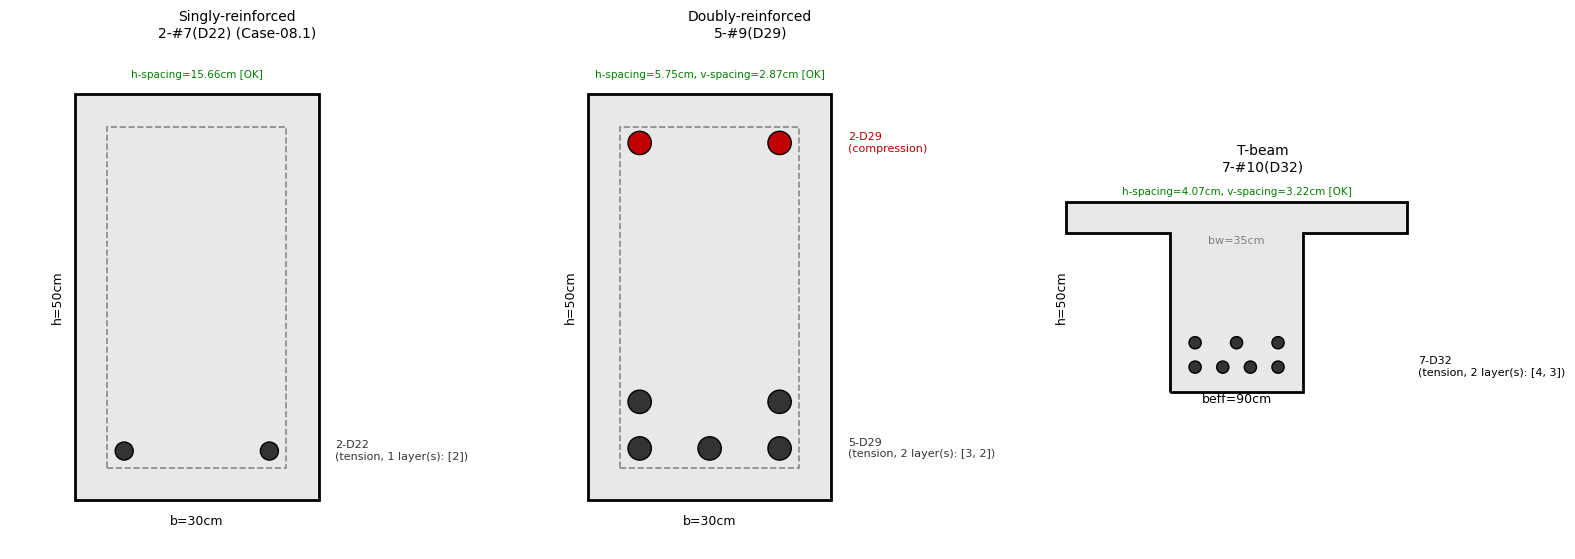

排筋間距檢查: 單筋=True, 雙筋=True, T形梁=True
單筋: 層數=1, 排列=[2]
雙筋: 層數=2, 排列=[3, 2], n_passes=2
T形梁: 層數=2, 排列=[4, 3], n_passes=2


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,6.5))

# 案例1: 現場重算Case-08.1的標準案例(跟該notebook的CASE完全一致), 不是抄一個舊數字過來
from rc_design import design_rebar
CASE_SINGLY = dict(Mu_kNm=112.5, b_cm=30.0, h_cm=50.0, cover=4.0)
r1 = design_rebar(**CASE_SINGLY)
_, ok1 = draw_rc_section(CASE_SINGLY['b_cm'], CASE_SINGLY['h_cm'], CASE_SINGLY['cover'],
                           r1['layout'], r1['bar_d'],
                           title=f"Singly-reinforced\n{r1['n_bars']}-{r1['bar_size']} (Case-08.1)", ax=axes[0])

# 案例2: 08.2雙筋設計結果——現在design_doubly_reinforced()會真的選筋號,
# 不再需要假設一個常用筋徑, 直接用r['bar_d']/r['layout']
if r['need_doubly']:
    _, ok2 = draw_rc_section(CASE_DR['b_cm'], CASE_DR['h_cm'], 4.0, r['layout'], r['bar_d'],
                               As_prime_cm2=r['As_prime'], d_prime_cm=CASE_DR['d_prime_cm'],
                               title=f"Doubly-reinforced\n{r['n_bars']}-{r['bar_size']}", ax=axes[1])
else:
    axes[1].text(0.5, 0.5, "need_doubly=False\n(no doubly-reinforced result to plot)",
                  ha='center', va='center', transform=axes[1].transAxes, fontsize=9)
    axes[1].axis('off')
    ok2 = None

# 案例3: 08.2 T形梁設計結果, 同樣直接用rB['bar_d']/rB['layout'](真實選筋結果)
_, ok3 = draw_Tbeam_section(bw_cm=rB['bw'], beff_cm=rB['beff'], hf_cm=rB['hf'], h_cm=CASE_TB_B['h_cm'],
                              cover_cm=4.0, layout=rB['layout'], bar_diameter_cm=rB['bar_d'],
                              title=f"T-beam\n{rB['n_bars']}-{rB['bar_size']}", ax=axes[2])

plt.tight_layout()
plt.show()

print(f"排筋間距檢查: 單筋={ok1}, 雙筋={ok2}, T形梁={ok3}")
print(f"單筋: 層數={r1['layout']['n_layers']}, 排列={r1['layout']['layout']}")
if r['need_doubly']:
    print(f"雙筋: 層數={r['layout']['n_layers']}, 排列={r['layout']['layout']}, n_passes={r['n_passes']}")
print(f"T形梁: 層數={rB['layout']['n_layers']}, 排列={rB['layout']['layout']}, n_passes={rB['n_passes']}")

if not ok3:
    print("\n[誠實記錄] 這個T形梁案例即使排成雙層仍然不夠, 需要加大bw或改用更大直徑鋼筋")

## 小結

- `design_doubly_reinforced()`:單筋不夠時的雙筋梁設計,含「壓力筋
  是否真的降伏」的關鍵檢查——**過程中抓到一個真實 bug**($A_{s2}$
  計算漏除 $\phi$),用應變相容法交叉驗證才發現,修正後差距從
  10.16% 降到 0.26%
- `design_Tbeam()`:T 形梁設計,先試矩形梁、不夠才拆翼板+腹板,
  兩種分支都用應變相容法驗證過(matched 0.00%、0.26% 量級)
- Case-08.3 起會延伸到剪力設計(`design_stirrups()`)